In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Histograma

Un histograma es un tipo de gráfico usado en estadistica para representar la distribición de un conjunto de datos numéricos.

Se construye dividiendo el rango de los datos en intervalos o clases (también llamados bins), y luego se cuentan cuántos datos caen 

In [2]:
df = pd.read_csv('./bigotes.csv')
df

,A,B
0,3,2
1,3,2
2,3,4
3,1,6
4,5,6
...,...,...
94,4,5
95,5,6
96,2,3
97,4,5


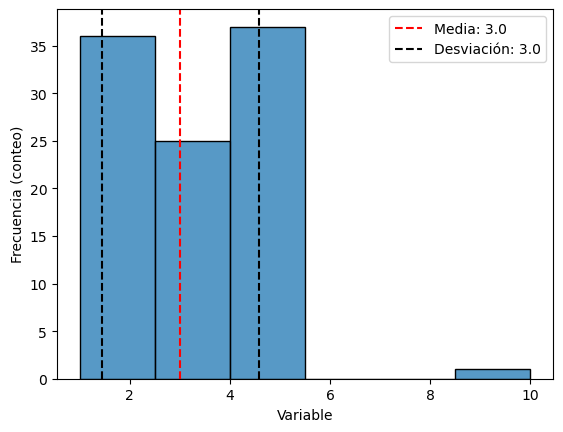

In [3]:
#Histograma de A
ax = sns.histplot(data=df['A'], bins=6)
ax.set_xlabel('Variable')
ax.set_ylabel('Frecuencia (conteo)')
media, std = df['A'].mean(), df['A'].std()
ax.axvline(media, color='red', linestyle='--', label=f'Media: {media:.1f}')
ax.axvline(media+std, color='black', linestyle='--', label=f'Desviación: {media:.1f}')
ax.axvline(media-std, color='black', linestyle='--')
ax.legend()

### Resultados

- Tenemos una mediana de 3
- IQR de 2
- Los datos están entre 1 y 5
- La distribución de los datos es asimetrica, la mediana esta a la mitad de la caja, porque los bigotes están a la misma distancia
- Tenemos un valor extremo de 10

### Ejercicios

1. Hacer lo mismo para los datos B
2. Ocupar el dataset de crímenes y hace lo mismo para las variables numéricas

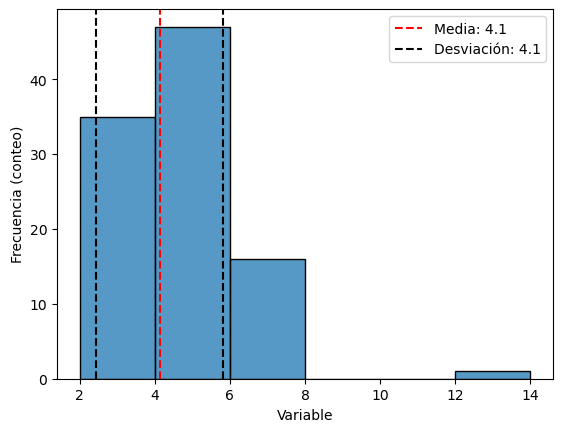

In [4]:
#Histograma de B
ax = sns.histplot(data=df['B'], bins=6)
ax.set_xlabel('Variable')
ax.set_ylabel('Frecuencia (conteo)')
media, std = df['B'].mean(), df['B'].std()
ax.axvline(media, color='red', linestyle='--', label=f'Media: {media:.1f}')
ax.axvline(media+std, color='black', linestyle='--', label=f'Desviación: {media:.1f}')
ax.axvline(media-std, color='black', linestyle='--')
ax.legend()

In [5]:
def calcular_iqr(data):
    #Calcular cuartiles 1 y 3
    qs = data.quantile([0.25, 0.75])

    #Calcular IQR
    iqr = qs[0.75] - qs[0.25]
    return iqr, qs[0.25], qs[0.75]

In [6]:
print('B:')

IQR,Q1,Q3 = calcular_iqr(df['B'])
print(f'\tMedia: {df['B'].mean()}')
print(f'\tMediana: {df['B'].median()}')
print(f'\tDesviación Estándar: {df['B'].std()}')
print(f'\tIQR: {IQR}')
print(f'\tQ1: {Q1}')
print(f'\tQ3: {Q3}')
print(f'\tMin: {df['B'].min()}')
print(f'\tMax: {df['B'].max()}')
print(f'\tBigote Min: {Q1-(1.5*IQR)}')
print(f'\tBigote Max: {Q3+(1.5*IQR)}')

B:
	Media: 4.1313131313131315
	Mediana: 4.0
	Desviación Estándar: 1.6881729324710337
	IQR: 2.0
	Q1: 3.0
	Q3: 5.0
	Min: 2
	Max: 14
	Bigote Min: 0.0
	Bigote Max: 8.0


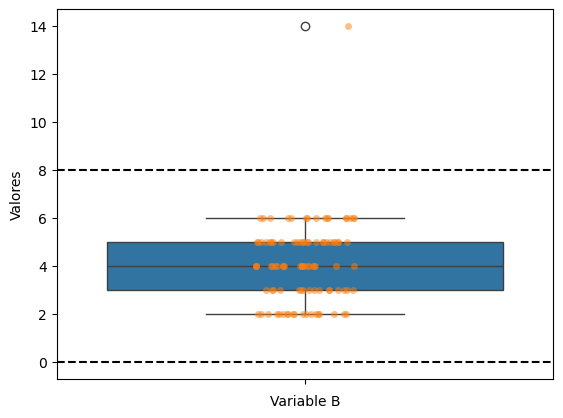

In [7]:
#Boxplot
ax = sns.boxplot(data=df['B'], showfliers=True) #showfilters=False quitar los outliers
ax = sns.stripplot(data=df['B'], jitter=True, alpha=0.5) #poder superponer los datos
ax.set_xlabel('Variable B')
ax.set_ylabel('Valores')
ax.axhline((Q1-(1.5*IQR)), color='black', linestyle='--')
ax.axhline((Q3+(1.5*IQR)), color='black', linestyle='--')

### Resultados

- Tenemos una mediana de 4
- IQR de 2
- Los datos están entre 2 y 8
- La distribución de los datos es asimetrica, la mediana esta a la mitad de la caja, porque los bigotes están a la misma distancia
- Tenemos un valor extremo de 14

Para crímenes

In [8]:
df_crimenes = pd.read_csv('./crimenes.csv')
df_crimenes

,State,Population,Murder.Rate,Abbreviation
0,Alabama,4779736,5.7,AL
1,Alaska,710231,5.6,AK
2,Arizona,6392017,4.7,AZ
3,Arkansas,2915918,5.6,AR
4,California,37253956,4.4,CA
5,Colorado,5029196,2.8,CO
6,Connecticut,3574097,2.4,CT
7,Delaware,897934,5.8,DE
8,Florida,18801310,5.8,FL
9,Georgia,9687653,5.7,GA


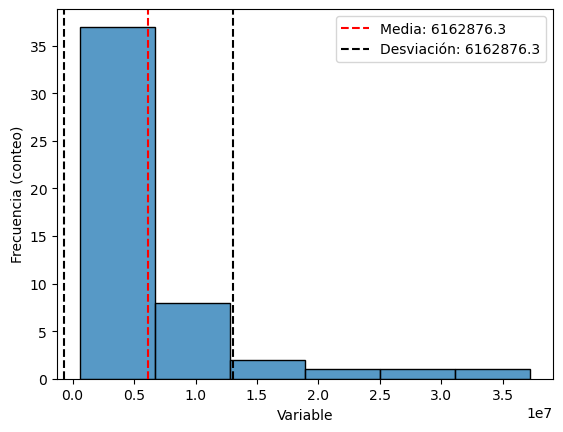

In [9]:
#Histograma de Population
ax = sns.histplot(data=df_crimenes['Population'], bins=6)
ax.set_xlabel('Variable')
ax.set_ylabel('Frecuencia (conteo)')
media, std = df_crimenes['Population'].mean(), df_crimenes['Population'].std()
ax.axvline(media, color='red', linestyle='--', label=f'Media: {media:.1f}')
ax.axvline(media+std, color='black', linestyle='--', label=f'Desviación: {media:.1f}')
ax.axvline(media-std, color='black', linestyle='--')
ax.legend()

In [10]:
print('Population:')

IQR,Q1,Q3 = calcular_iqr(df_crimenes['Population'])
print(f'\tMedia: {df_crimenes['Population'].mean()}')
print(f'\tMediana: {df_crimenes['Population'].median()}')
print(f'\tDesviación Estándar: {df_crimenes['Population'].std()}')
print(f'\tIQR: {IQR}')
print(f'\tQ1: {Q1}')
print(f'\tQ3: {Q3}')
print(f'\tMin: {df_crimenes['Population'].min()}')
print(f'\tMax: {df_crimenes['Population'].max()}')
print(f'\tBigote Min: {Q1-(1.5*IQR)}')
print(f'\tBigote Max: {Q3+(1.5*IQR)}')

Population:
	Media: 6162876.3
	Mediana: 4436369.5
	Desviación Estándar: 6848235.347401142
	IQR: 4847308.0
	Q1: 1833004.25
	Q3: 6680312.25
	Min: 563626
	Max: 37253956
	Bigote Min: -5437957.75
	Bigote Max: 13951274.25


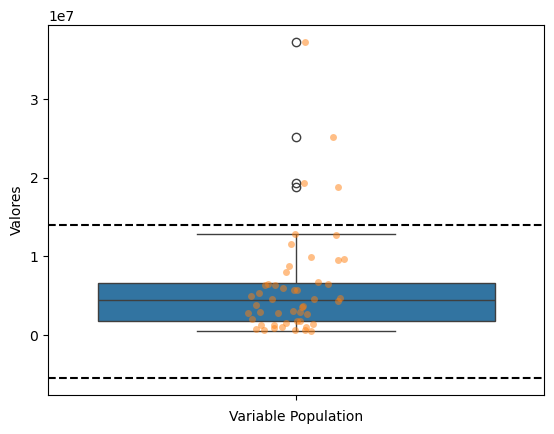

In [11]:
#Boxplot
ax = sns.boxplot(data=df_crimenes['Population'], showfliers=True) #showfilters=False quitar los outliers
ax = sns.stripplot(data=df_crimenes['Population'], jitter=True, alpha=0.5) #poder superponer los datos
ax.set_xlabel('Variable Population')
ax.set_ylabel('Valores')
ax.axhline((Q1-(1.5*IQR)), color='black', linestyle='--')
ax.axhline((Q3+(1.5*IQR)), color='black', linestyle='--')

### Resultados

- Tenemos una mediana de 4,436,369
- IQR de 4,847,308
- Los datos están entre 1,000,000 y 8
- La distribución de los datos es asimetrica, la mediana esta a la mitad de la caja, porque los bigotes están a la misma distancia
- Tenemos un valor extremo de 14

In [12]:
print('Murder.Rate:')

IQR,Q1,Q3 = calcular_iqr(df_crimenes['Murder.Rate'])
print(f'\tMedia: {df_crimenes['Murder.Rate'].mean()}')
print(f'\tMediana: {df_crimenes['Murder.Rate'].median()}')
print(f'\tDesviación Estándar: {df_crimenes['Murder.Rate'].std()}')
print(f'\tIQR: {IQR}')
print(f'\tQ1: {Q1}')
print(f'\tQ3: {Q3}')
print(f'\tMin: {df_crimenes['Murder.Rate'].min()}')
print(f'\tMax: {df_crimenes['Murder.Rate'].max()}')
print(f'\tBigote Min: {Q1-(1.5*IQR)}')
print(f'\tBigote Max: {Q3+(1.5*IQR)}')

Murder.Rate:
	Media: 4.066
	Mediana: 4.0
	Desviación Estándar: 1.915736124302923
	IQR: 3.125
	Q1: 2.425
	Q3: 5.55
	Min: 0.9
	Max: 10.3
	Bigote Min: -2.2625
	Bigote Max: 10.2375


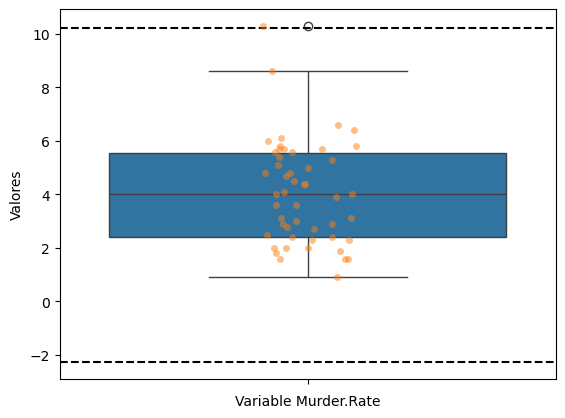

In [15]:
#Boxplot
ax = sns.boxplot(data=df_crimenes['Murder.Rate'], showfliers=True) #showfilters=False quitar los outliers
ax = sns.stripplot(data=df_crimenes['Murder.Rate'], jitter=True, alpha=0.5) #poder superponer los datos
ax.set_xlabel('Variable Murder.Rate')
ax.set_ylabel('Valores')
ax.axhline((Q1-(1.5*IQR)), color='black', linestyle='--')
ax.axhline((Q3+(1.5*IQR)), color='black', linestyle='--')